# modeling2.ipynb — Corrected Pipeline (No Data Leakage)\n\n> **Refer to `checkpoints/checkpoint5.md`** for a full summary of what was done, why the original pipeline had data leakage, and the key results from both pipelines side by side.\n\n**The problem with modeling.ipynb:**  \nStatistical feature selection (t-test + Mann-Whitney) was run on all 43 patients *before* the train/test split. The test set patients influenced which 200 peptides were chosen, giving the model an unfair advantage and producing artificially perfect scores (100% accuracy, F1, ROC-AUC).\n\n**The fix applied here:**  \n1. Split into train / validation / test **first**\n2. Run statistical tests on **training patients only** (25 patients)\n3. Select top 200 peptides from training p-values only\n4. Apply those same 200 peptides to validation and test (no re-selection)\n5. Impute and scale using training-set statistics only\n6. Train the same three models and compare validation then test results"

## Step 1 — Load the full cleaned dataset

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

df = pd.read_csv("variants_filtered.tsv", sep="\t", index_col=0)

condition = df["Condition"]
X = df.drop(columns=["Condition"])

LABEL_MAP = {"Non-severe-COVID-19": 0, "Severe-COVID-19": 1}
y = condition.map(LABEL_MAP)

print(f"Full dataset: {X.shape[0]} patients × {X.shape[1]} peptides")
print(f"\nCondition counts:")
print(condition.value_counts())

Full dataset: 43 patients × 101461 peptides

Condition counts:
Condition
Non-severe-COVID-19    25
Severe-COVID-19        18
Name: count, dtype: int64


## Step 2 — Split into train / validation / test FIRST

This is the key fix. The split happens before any feature selection, so the test set has zero influence on which peptides are chosen.

In [2]:
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42

# Hold out 20% as the final test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

# Split remaining 80% into train and validation
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, stratify=y_trainval, random_state=RANDOM_STATE
)

print(f"Train      : {X_train.shape[0]} patients ({y_train.sum()} Severe, {(y_train==0).sum()} Non-severe)")
print(f"Validation : {X_val.shape[0]} patients ({y_val.sum()} Severe, {(y_val==0).sum()} Non-severe)")
print(f"Test       : {X_test.shape[0]} patients ({y_test.sum()} Severe, {(y_test==0).sum()} Non-severe)")

Train      : 25 patients (10 Severe, 15 Non-severe)
Validation : 9 patients (4 Severe, 5 Non-severe)
Test       : 9 patients (4 Severe, 5 Non-severe)


## Step 3 — Run statistical tests on training patients only

t-test and Mann-Whitney are run exclusively on `X_train` (25 patients).  
The validation and test sets are not touched at this stage.

In [3]:
from scipy.stats import ttest_ind, mannwhitneyu

# Use only training labels for the statistical comparison
condition_train = y_train.map({0: "Non-severe-COVID-19", 1: "Severe-COVID-19"})

results = []

for peptide in X_train.columns:
    severe_vals    = X_train.loc[condition_train == "Severe-COVID-19",     peptide].dropna()
    nonsevere_vals = X_train.loc[condition_train == "Non-severe-COVID-19", peptide].dropna()

    if len(severe_vals) < 3 or len(nonsevere_vals) < 3:
        results.append({"Peptide": peptide, "t_pvalue": np.nan, "mannwhitney_pvalue": np.nan})
        continue

    _, t_p  = ttest_ind(severe_vals, nonsevere_vals, equal_var=False, nan_policy="omit")
    try:
        _, mw_p = mannwhitneyu(severe_vals, nonsevere_vals, alternative="two-sided")
    except ValueError:
        mw_p = np.nan

    results.append({"Peptide": peptide, "t_pvalue": t_p, "mannwhitney_pvalue": mw_p})

stats_train = (
    pd.DataFrame(results)
    .sort_values(["mannwhitney_pvalue", "t_pvalue"], na_position="last")
    .reset_index(drop=True)
)

valid_tests = stats_train["mannwhitney_pvalue"].notna().sum()
print(f"Peptides with valid p-values (training set only): {valid_tests:,}")
print(f"\nTop 10 peptides by Mann-Whitney p-value:")
print(stats_train.head(10).to_string(index=False))

Peptides with valid p-values (training set only): 51,264

Top 10 peptides by Mann-Whitney p-value:
                                                                     Peptide  t_pvalue  mannwhitney_pvalue
                                 R.[304.207]FFGHGAED(S,207.144)LADQAANEWGR.S  0.034962            0.000046
                                 R.[304.207]FFGHGAED(S,308.212)LADQAANEWGR.S  0.107562            0.000075
                             R.[304.207]EANYIG(S,304.212)D(K,304.207)YFHAR.G  0.058706            0.000116
                          R.[304.207]LTG(R,-19.035)GAEDSLADQAAN(K,304.207).W  0.122801            0.000145
            K.[304.207](T,-13.036)(C,57.021)VADESAEN(C,57.021)D(K,304.207).S  0.002763            0.000280
R.{290.173}[304.207]EGT(C,57.021)PEAPTDE(C,57.021)(K,304.207)PV(K,304.207).W  0.000179            0.000346
                       R.[304.207](F,-13.032)(K,304.207)DLGEENF(K,304.207).A  0.000771            0.000346
                          R.[304.207](L,285.1

## Step 4 — Select top 200 peptides from training data only

The 200 peptides are chosen based solely on training-set p-values.  
These same 200 columns are then applied to validation and test — no re-selection.

In [4]:
N_FEATURES = 200

selected_peptides = (
    stats_train
    .dropna(subset=["mannwhitney_pvalue"])
    .head(N_FEATURES)["Peptide"]
    .tolist()
)

# Subset all three splits to the same 200 peptides
X_train_sel = X_train[selected_peptides]
X_val_sel   = X_val[selected_peptides]
X_test_sel  = X_test[selected_peptides]

print(f"Selected peptides : {len(selected_peptides)}")
print(f"Train shape       : {X_train_sel.shape}")
print(f"Validation shape  : {X_val_sel.shape}")
print(f"Test shape        : {X_test_sel.shape}")
print(f"\nBest p-value (Mann-Whitney, training only): {stats_train['mannwhitney_pvalue'].iloc[0]:.6f}")

Selected peptides : 200
Train shape       : (25, 200)
Validation shape  : (9, 200)
Test shape        : (9, 200)

Best p-value (Mann-Whitney, training only): 0.000046


## Step 5 — Build model pipelines

Same three models as modeling.ipynb. Each pipeline handles imputation and scaling internally using training-set statistics only.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    "logistic_regression_l2": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(
            penalty="l2", C=1.0, class_weight="balanced",
            max_iter=5000, random_state=RANDOM_STATE,
        )),
    ]),
    "logistic_regression_l1": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
        ("model",   LogisticRegression(
            penalty="l1", C=0.2, solver="liblinear", class_weight="balanced",
            max_iter=5000, random_state=RANDOM_STATE,
        )),
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model",   RandomForestClassifier(
            n_estimators=500, max_depth=3, min_samples_leaf=2,
            class_weight="balanced", random_state=RANDOM_STATE,
        )),
    ]),
}

print("Models ready:")
for name in models:
    print("-", name)

Models ready:
- logistic_regression_l2
- logistic_regression_l1
- random_forest


## Step 6 — Train on training set, evaluate on validation set

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

comparison_rows = []
fitted_models   = {}

for name, pipeline in models.items():
    pipeline.fit(X_train_sel, y_train)
    fitted_models[name] = pipeline

    y_pred  = pipeline.predict(X_val_sel)
    y_score = pipeline.predict_proba(X_val_sel)[:, 1]

    comparison_rows.append({
        "model"            : name,
        "accuracy"         : accuracy_score(y_val, y_pred),
        "precision_severe" : precision_score(y_val, y_pred, zero_division=0),
        "recall_severe"    : recall_score(y_val, y_pred, zero_division=0),
        "f1_severe"        : f1_score(y_val, y_pred, zero_division=0),
        "roc_auc"          : roc_auc_score(y_val, y_score),
    })

model_comparison = (
    pd.DataFrame(comparison_rows)
    .sort_values(["f1_severe", "roc_auc", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

print("Validation results:")
print(model_comparison.to_string(index=False))

Validation results:
                 model  accuracy  precision_severe  recall_severe  f1_severe  roc_auc
logistic_regression_l1  0.888889               0.8            1.0   0.888889     0.95
         random_forest  0.888889               0.8            1.0   0.888889     0.90
logistic_regression_l2  0.888889               0.8            1.0   0.888889     0.80


## Step 7 — Select the best model and evaluate on the test set

The test set is used exactly once, after model selection is complete.

In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

best_model_name = model_comparison.loc[0, "model"]
best_model      = fitted_models[best_model_name]

print(f"Best validation model: {best_model_name}")

# ── Test set predictions ──────────────────────────────────
y_pred_test  = best_model.predict(X_test_sel)
y_score_test = best_model.predict_proba(X_test_sel)[:, 1]

# Per-patient breakdown
test_predictions = pd.DataFrame({
    "patient"            : X_test_sel.index,
    "true_condition"     : y_test.map({0: "Non-severe", 1: "Severe"}),
    "predicted_condition": pd.Series(y_pred_test, index=y_test.index).map({0: "Non-severe", 1: "Severe"}),
    "severe_probability" : y_score_test,
    "correct"            : (y_pred_test == y_test.values),
})
print("\nPer-patient predictions:")
print(test_predictions.to_string(index=False))

# ── Summary metrics ───────────────────────────────────────
print("\n── Test Set Metrics ──────────────────────────────")
print(f"Accuracy  : {accuracy_score(y_test, y_pred_test):.3f}")
print(f"Precision : {precision_score(y_test, y_pred_test, zero_division=0):.3f}")
print(f"Recall    : {recall_score(y_test, y_pred_test, zero_division=0):.3f}")
print(f"F1        : {f1_score(y_test, y_pred_test, zero_division=0):.3f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_score_test):.3f}")
print()
print(classification_report(y_test, y_pred_test,
      target_names=["Non-severe", "Severe"], zero_division=0))

Best validation model: logistic_regression_l1

Per-patient predictions:
                         patient true_condition predicted_condition  severe_probability  correct
        Non-severe-COVID-19.XG15     Non-severe          Non-severe            0.386305     True
        Non-severe-COVID-19.XG22     Non-severe          Non-severe            0.255532     True
            Severe-COVID-19.XG46         Severe              Severe            0.611404     True
        Non-severe-COVID-19.XG16     Non-severe          Non-severe            0.303418     True
            Severe-COVID-19.XG36         Severe              Severe            0.555494     True
         Non-severe-COVID-19.XG4     Non-severe              Severe            0.596504    False
Severe-COVID-19.Patient-group-ZX         Severe              Severe            0.667239     True
            Severe-COVID-19.XG39         Severe              Severe            0.612817     True
        Non-severe-COVID-19.XG19     Non-severe        

## Step 8 — Confusion Matrix

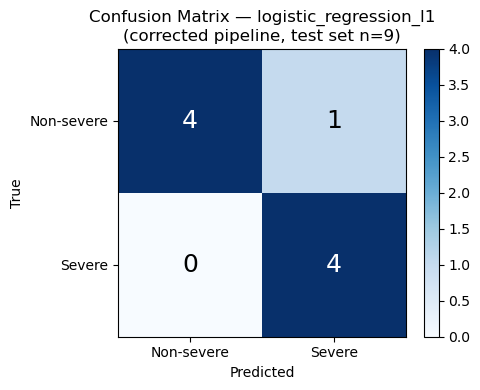

True Negatives  (Non-severe → Non-severe): 4
False Positives (Non-severe → Severe)    : 1
False Negatives (Severe → Non-severe)    : 0
True Positives  (Severe → Severe)        : 4


In [8]:
cm     = confusion_matrix(y_test, y_pred_test)
labels = ["Non-severe", "Severe"]

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — {best_model_name}\n(corrected pipeline, test set n=9)")

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                fontsize=18, color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Non-severe → Non-severe): {tn}")
print(f"False Positives (Non-severe → Severe)    : {fp}")
print(f"False Negatives (Severe → Non-severe)    : {fn}")
print(f"True Positives  (Severe → Severe)        : {tp}")

## Step 9 — Precision-Recall Curve

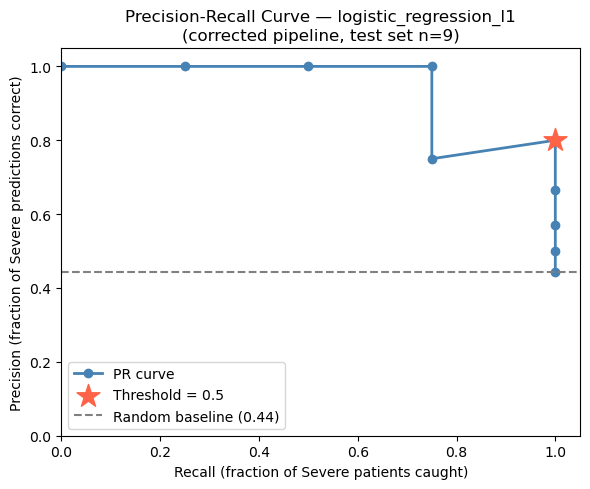

In [9]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_score_test)
default_idx = np.argmin(np.abs(thresholds - 0.5))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(recall_vals, precision_vals, marker="o", color="steelblue", linewidth=2, label="PR curve")
ax.scatter(recall_vals[default_idx], precision_vals[default_idx],
           marker="*", s=300, color="tomato", zorder=5, label="Threshold = 0.5")
ax.axhline(y_test.mean(), linestyle="--", color="grey",
           label=f"Random baseline ({y_test.mean():.2f})")
ax.set_xlabel("Recall (fraction of Severe patients caught)")
ax.set_ylabel("Precision (fraction of Severe predictions correct)")
ax.set_title(f"Precision-Recall Curve — {best_model_name}\n(corrected pipeline, test set n=9)")
ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

## Step 10 — Compare with modeling.ipynb (leaky pipeline)

Side-by-side comparison of validation and test metrics between the two pipelines.

In [10]:
import joblib

# Load the leaky pipeline's best model results for comparison
leaky_comparison = pd.read_csv("models/checkpoint4_model_comparison.tsv", sep="\t")
leaky_best = leaky_comparison.iloc[0]

# Corrected pipeline — best model validation metrics
corrected_best_val = model_comparison.iloc[0]

# Corrected pipeline — test metrics
corrected_test = {
    "accuracy"         : accuracy_score(y_test, y_pred_test),
    "precision_severe" : precision_score(y_test, y_pred_test, zero_division=0),
    "recall_severe"    : recall_score(y_test, y_pred_test, zero_division=0),
    "f1_severe"        : f1_score(y_test, y_pred_test, zero_division=0),
    "roc_auc"          : roc_auc_score(y_test, y_score_test),
}

comparison = pd.DataFrame({
    "leaky_validation (modeling.ipynb)"       : leaky_best[["accuracy","precision_severe","recall_severe","f1_severe","roc_auc"]],
    "corrected_validation (modeling2.ipynb)"  : corrected_best_val[["accuracy","precision_severe","recall_severe","f1_severe","roc_auc"]],
    "corrected_test (modeling2.ipynb)"        : pd.Series(corrected_test),
}).T

print(f"Leaky pipeline best model     : {leaky_best['model']}")
print(f"Corrected pipeline best model : {best_model_name}")
print()
print(comparison.round(3).to_string())

Leaky pipeline best model     : logistic_regression_l2
Corrected pipeline best model : logistic_regression_l1

                                        accuracy precision_severe recall_severe f1_severe roc_auc
leaky_validation (modeling.ipynb)            1.0              1.0           1.0       1.0     1.0
corrected_validation (modeling2.ipynb)  0.888889              0.8           1.0  0.888889    0.95
corrected_test (modeling2.ipynb)        0.888889              0.8           1.0  0.888889    0.95


## Step 11 — Save the best model and selected peptides

In [11]:
import joblib
from pathlib import Path

MODEL_DIR = Path("./models")
MODEL_DIR.mkdir(exist_ok=True)

# Save the best model
joblib.dump(best_model, MODEL_DIR / "modeling2_best_model.joblib")

# Save the model name
(MODEL_DIR / "modeling2_best_model_name.txt").write_text(best_model_name + "\n")

# Save the 200 selected peptides in order — needed to match coefficients to names
pd.Series(selected_peptides).to_csv(
    MODEL_DIR / "modeling2_selected_peptides.txt", index=False, header=False
)

print(f"Saved to {MODEL_DIR}/")
print(f"  modeling2_best_model.joblib    — trained {best_model_name} pipeline")
print(f"  modeling2_best_model_name.txt  — best model name")
print(f"  modeling2_selected_peptides.txt — {len(selected_peptides)} peptides used as features")

Saved to models/
  modeling2_best_model.joblib    — trained logistic_regression_l1 pipeline
  modeling2_best_model_name.txt  — best model name
  modeling2_selected_peptides.txt — 200 peptides used as features
